<h1 style="color:#c8a2c8; font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">ImmoEliza Project</h1>  
<h2 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px;">ML content</h2>

<i><span style="color:orange">Note for the 03/07:</span> try to make all checking prints not blind.</i>

<h3 style="color:#c8a2c8; font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">3 - Baseline Model</h3>  
<u><h3 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px; margin-bottom: 0px; padding-bottom: 0px;">Multiple Linear Regression</h3></u>

<h3 style="font-weight:bold; margin-bottom: 0px; padding-bottom: 0px;">Historical and Programmatic reference point for the project</h3>

In [1]:
# import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
# other sklearn imports
from sklearn.base import BaseEstimator, TransformerMixin

print("✅ Libraries setup complete.")

✅ Libraries setup complete.


In [2]:
# file location dygnosis
print(f"⚠️ Python is reading from here:\n{os.getcwd()}.")

⚠️ Python is reading from here:
d:\Irene\Desktop\AI_&_Data_Science_training_BeCode\BeCode Projects\Preparation-for-Sprint-3-IMMO-ELIZA-Project\3_Baseline_Model\02-ModelingStructuredData.


In [3]:
# importing features train and test preprocessed datasets

PROP_TRAIN_PREPROC_CSV_PATH = "../../data/cleaned/properties_train_preprocessed.csv"
PROP_TEST_PREPROC_CSV_PATH = "../../data/cleaned/properties_test_preprocessed.csv"

properties_train_preproc = pd.read_csv(PROP_TRAIN_PREPROC_CSV_PATH)
properties_test_preproc = pd.read_csv(PROP_TEST_PREPROC_CSV_PATH)

print("✅ Preprocessed dataset for Train 'properties_train' successfully loaded.")
print("✅ Preprocessed dataset for Test 'properties_test' successfully loaded.")

✅ Preprocessed dataset for Train 'properties_train' successfully loaded.
✅ Preprocessed dataset for Test 'properties_test' successfully loaded.


In [4]:
# importing target train and test datasets

Y_TRAIN_CSV_PATH = "../../data/raw/train_test/y_train.csv"
Y_TEST_CSV_PATH = "../../data/raw/train_test/y_test.csv"

target_train = pd.read_csv(Y_TRAIN_CSV_PATH)
target_test = pd.read_csv(Y_TEST_CSV_PATH)

print("✅ Target dataset for Train 'target_train' successfully loaded.")
print("✅ Target dataset for Test 'target_test' successfully loaded.")

✅ Target dataset for Train 'target_train' successfully loaded.
✅ Target dataset for Test 'target_test' successfully loaded.


<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.1 - Training</h3>

**Model training**

In [5]:
# Initialization
# alpha=1.0 is the standard parameter for balancing regularization
regressor_model = Ridge(alpha=1.0)

# Train
X_train = properties_train_preproc
y_train = target_train

# Test
X_test = properties_test_preproc
y_test = target_test

# model training
regressor_model.fit(X_train, y_train)

print("✅ Ridge Regression model successfully trained on features in properties_train_preproc and target in target_train.")

✅ Ridge Regression model successfully trained on features in properties_train_preproc and target in target_train.


**Model Efficiency Check**

In [6]:
# model parameters extraction
b0 = regressor_model.intercept_
b1 = regressor_model.coef_

print(f'Model Intercept (b0): {b0}')
print(f'Model coefficients (b1): {b1}')

# calculating model performance score R²
train_r2 = regressor_model.score(X_train, y_train)

print(f"Train Score (R²): {round((train_r2 * 100), 2)} %.")


Model Intercept (b0): [465054.08869412]
Model coefficients (b1): [-6.18651798e+04  3.19944044e+04  1.50123752e+05  3.38077521e+04
 -1.38678601e+01  6.35177407e+04  1.66364054e+04  1.13610196e+04
  6.37548907e+03  3.39848137e+04  2.22949285e+04 -9.62216477e+01
  7.31378758e+03  2.02473968e+04  2.69385688e+04 -1.31955776e+04
  3.70199803e+03  1.28119768e+04  7.81437440e+03  5.63934597e+04
  5.28783314e+03 -7.12074901e+03  1.73222612e+05 -2.30823969e+03
  1.88176847e+05 -1.78936285e+04 -1.13610196e+04  1.42645899e+03
 -6.19488808e+04  6.85696070e+03 -3.61940379e+04 -6.21689703e+04
 -2.28454409e+04 -7.10982860e+04  5.13767499e+03 -2.03659718e+04
  4.23833244e+02  1.15088007e+05  9.16639157e+04  2.03453335e+04
  1.57040166e+05 -7.37176572e+04 -1.86077582e+05  1.81707375e+04
  6.45982785e+04  3.16618369e+04 -4.53845096e+03 -2.71233860e+04
 -4.68363528e+04  3.16618369e+04  8.13596784e+04  3.72522785e+03
 -1.62323320e+04 -1.06751765e+05 -6.12430884e+04  4.81989868e+04
 -6.46295563e+03  8.61600

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.2 - Prediction</h3>

**Prediction**

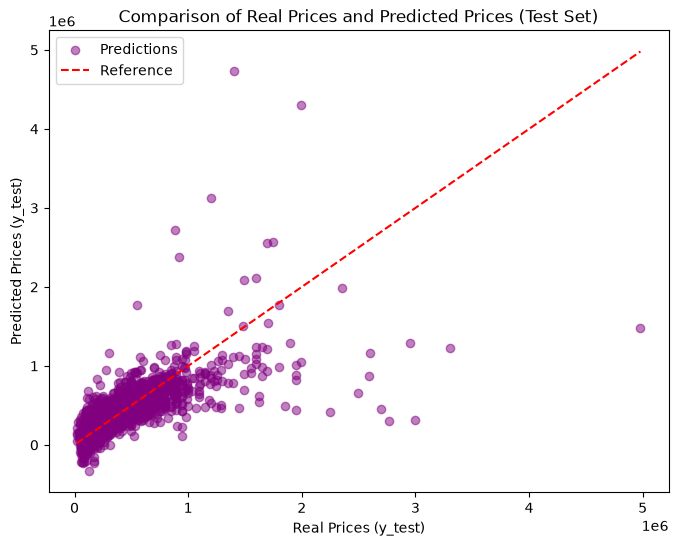

Test score is 44.07 %.
Switching to Test, there is a drop in performance of approximately 14.88 %.


In [7]:
# using .predict()
y_prediction_test = regressor_model.predict(X_test)

# plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_prediction_test, color='purple', alpha=0.5, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Reference')

plt.xlabel('Real Prices (y_test)')
plt.ylabel('Predicted Prices (y_test)')
plt.title('Comparison of Real Prices and Predicted Prices (Test Set)')
plt.legend()
plt.show()

# checking score on X_test and y_test
test_r2 = regressor_model.score(X_test, y_test)

print(f'Test score is {round(((test_r2) * 100), 2)} %.')
print(f'Switching to Test, there is a drop in performance of approximately {round((((train_r2 - test_r2) / train_r2) * 100), 2)} %.')

Ridge seems to return an acceptable estimate for price of stanard market properties.  
But as price gets higher, the purple points tend to deviate markedly from the red line, with **almost all of them positioned below** it.  

This means there is **Underfitting** on high prices &rarr; need to switch to non-linear models, such as <span style="color:#c8a2c8; font-weight:bold;">Random Forest</span>, in the next notebook

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.3 - Absolute Error Metrics</h3>

To calculate error in euro of the model &rarr; **MAE** (Mean Absolute Error) and **RMSE** (Root Mean Squared Error).

In [8]:
# prediction on Train
y_prediction_train = regressor_model.predict(X_train)

# calculate metrics for Train
mae_train = mean_absolute_error(y_train, y_prediction_train)
rmse_train = np.sqrt(mae_train)

# calculate metrics for Test
mae_test = mean_absolute_error(y_test, y_prediction_test)
rmse_test = np.sqrt(mae_test)

print(f"📊 Train -> MAE: {mae_train:,.2f} € | RMSE: {rmse_train:,.2f} €")
print(f"📊 Test -> MAE: {mae_test:,.2f} € | RMSE: {rmse_test:,.2f} €")


📊 Train -> MAE: 129,456.09 € | RMSE: 359.80 €
📊 Test -> MAE: 127,961.77 € | RMSE: 357.72 €


<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.4 - Residual Analysis</h3>

In [13]:
# verify objects shape
print(f'y_test type & shape: {type(y_test), y_test.shape}')
print(f'y_prediction_test type & shape: {type(y_prediction_test), y_prediction_test.shape}')

y_test type & shape: (<class 'pandas.DataFrame'>, (2480, 1))
y_prediction_test type & shape: (<class 'numpy.ndarray'>, (2480,))


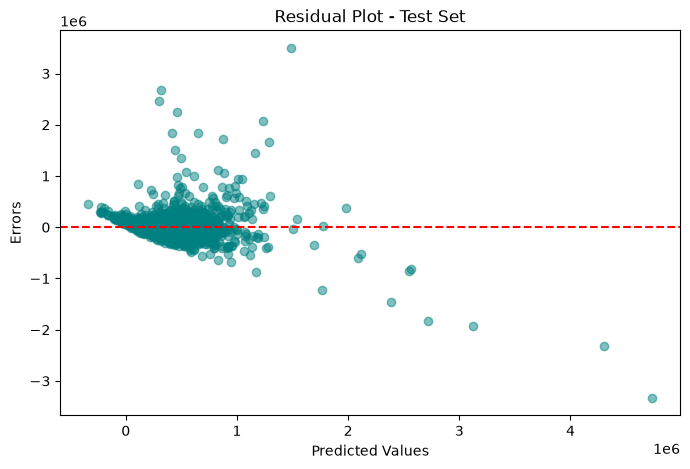

In [16]:
# calculate residuals
# excract first (and only) column of 2D y_test
resid_test = y_test.iloc[:, 0] - y_prediction_test

# plot
plt.figure(figsize=(8,5))
plt.scatter(y_prediction_test, resid_test, color='teal', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Errors')
plt.title('Residual Plot - Test Set')
plt.show()

- The error variance is not constant. This means the model is not uniformly accurate: it is moderately reliable for low-priced homes but becomes increasingly unstable and blind as the property value rises.  

- The model suffers from a systematic bias in the luxury segment. A straight line lacks the flexibility to curve upwards as prices rise exponentially; consequently, it "cuts straight across," grossly underestimating the most expensive properties.  

- If the linear model were extracting all the useful signal from the data, the residuals would appear as white noise: a shapeless, symmetrical, and purely random cloud around the red zero line. The fact that there is such a distinct geometric pattern demonstrates that there is still information in the data that the model is failing to capture, because it is attempting to force a linear logic onto a market that is not linear.

I now have enough information to **close the Baseline Model notebook and move on to a new model**.

<h3 style="color:#c8a2c8; margin-bottom: 0px; padding-bottom: 0px;">3.5 - Pre-modeling</h3>  
<h4 style="color:#c8a2c8; margin-top: 0px; padding-top: 0px;">Preventive Sanity Check</h4>